In [2]:
# Install required packages with compatible versions
# Fix numpy/mediapipe compatibility issue
!pip uninstall -y numpy
!pip install numpy==1.26.4 mediapipe opencv-python-headless scikit-learn -q

import os
import re
import json
import numpy as np
from pathlib import Path
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import gc


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 10.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [1]:
import kagglehub
from google.colab import userdata
import os

# Store your credentials in Colab Secrets first (see below)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Download latest version
path = kagglehub.dataset_download("mwakalucky/casl-w60")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'casl-w60' dataset.
Path to dataset files: /kaggle/input/casl-w60


In [2]:
import torch # <--- Add this line!
import os
# Configuration (should match training config)
CONFIG = {
    'num_frames': 16,
    'batch_size': 4,
    'img_size': 224,
    'resize_size': 256,
    'num_classes': 60,
    'num_workers': 0,
    'pose_dim': 126,
}

# Paths - UPDATE THESE
MODEL_PATH = '/content/best_multimodal_model.pth'  # Upload your model here
VAL_DATA_PATH = f'{path}/CASL/val'  # Path to validation data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"\nConfiguration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Using device: cpu

Configuration:
  num_frames: 16
  batch_size: 4
  img_size: 224
  resize_size: 256
  num_classes: 60
  num_workers: 0
  pose_dim: 126


In [3]:
# MediaPipe Hand Pose Extractor
class HandPoseExtractor:
    """Extract hand keypoints using MediaPipe"""

    def __init__(self):
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=2,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def extract_pose(self, frame):
        """Extract hand landmarks from a frame"""
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.hands.process(frame_rgb)

        if not results.multi_hand_landmarks:
            return np.zeros(126, dtype=np.float32)

        all_landmarks = []
        for hand_landmarks in results.multi_hand_landmarks[:2]:
            landmarks = []
            for landmark in hand_landmarks.landmark:
                landmarks.extend([landmark.x, landmark.y, landmark.z])
            all_landmarks.extend(landmarks)

        while len(all_landmarks) < 126:
            all_landmarks.extend([0.0] * 63)

        return np.array(all_landmarks[:126], dtype=np.float32)

    def close(self):
        self.hands.close()

print("✓ HandPoseExtractor defined")

✓ HandPoseExtractor defined


In [4]:
# Dataset Class
class CASLMultimodalDataset(Dataset):
    """Dataset that returns both RGB video AND hand pose sequences"""

    def __init__(self, video_dir, num_frames=16, img_size=224, resize_size=256, extract_pose=True):
        self.video_dir = Path(video_dir)
        self.num_frames = num_frames
        self.img_size = img_size
        self.resize_size = resize_size
        self.extract_pose = extract_pose

        if extract_pose:
            self.pose_extractor = HandPoseExtractor()

        # Load videos
        self.samples = []
        for video_path in sorted(self.video_dir.glob('**/*.mp4')):
            filename = video_path.stem
            match = re.match(r'^G(\d{3})', filename)
            if match:
                label = int(match.group(1)) - 1
                if 0 <= label < 60:
                    self.samples.append((str(video_path), label))

        print(f"  Loaded {len(self.samples)} videos")

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.samples)

    def load_video(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
        cap.release()
        return frames

    def sample_frames(self, frames, num_frames):
        if len(frames) == 0:
            return [np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
                    for _ in range(num_frames)]

        if len(frames) <= num_frames:
            indices = list(range(len(frames))) * (num_frames // len(frames) + 1)
            indices = indices[:num_frames]
        else:
            step = len(frames) / num_frames
            indices = [int(i * step) for i in range(num_frames)]

        return [frames[i] for i in indices]

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]

        try:
            frames = self.load_video(video_path)
            frames = self.sample_frames(frames, self.num_frames)

            # Extract hand poses
            if self.extract_pose:
                poses = []
                for frame in frames:
                    pose = self.pose_extractor.extract_pose(frame)
                    poses.append(pose)
                pose_sequence = torch.tensor(np.stack(poses), dtype=torch.float32)
            else:
                pose_sequence = torch.zeros(self.num_frames, 126)

            # Process RGB frames
            processed_frames = []
            for frame in frames:
                h, w = frame.shape[:2]

                if h < w:
                    new_h = self.resize_size
                    new_w = int(w * (self.resize_size / h))
                else:
                    new_w = self.resize_size
                    new_h = int(h * (self.resize_size / w))

                frame = cv2.resize(frame, (new_w, new_h))

                start_h = (new_h - self.img_size) // 2
                start_w = (new_w - self.img_size) // 2
                frame = frame[start_h:start_h+self.img_size,
                            start_w:start_w+self.img_size]

                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = np.asarray(frame, dtype=np.float32)
                frame = torch.from_numpy(frame).permute(2, 0, 1) / 255.0
                frame = self.normalize(frame)
                processed_frames.append(frame)

            rgb_video = torch.stack(processed_frames, dim=0).permute(1, 0, 2, 3)

            return rgb_video, pose_sequence, label, video_path

        except Exception as e:
            print(f"Error loading {video_path}: {e}")
            rgb_video = torch.zeros(3, self.num_frames, self.img_size, self.img_size)
            pose_sequence = torch.zeros(self.num_frames, 126)
            return rgb_video, pose_sequence, label, video_path

    def __del__(self):
        if hasattr(self, 'pose_extractor'):
            self.pose_extractor.close()

print("✓ CASLMultimodalDataset defined")

NameError: name 'Dataset' is not defined

In [11]:
# Model Definition
# Try to import best available video model
MODEL_TYPE = None
try:
    from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
    MODEL_TYPE = "MViT_V2_S"
    print("✓ Using MViT V2 Small (BEST)")
except ImportError:
    try:
        from torchvision.models.video import mvit_v1_b, MViT_V1_B_Weights
        MODEL_TYPE = "MViT_V1_B"
        print("✓ Using MViT V1 Base")
    except ImportError:
        from torchvision.models.video import r3d_18, R3D_18_Weights
        MODEL_TYPE = "R3D_18"
        print("⚠️ Falling back to R3D-18")

class MultimodalSignLanguageModel(nn.Module):
    """Two-stream model with video backbone + BiLSTM for pose"""

    def __init__(self, num_classes, pose_dim=126, model_type="MViT_V2_S"):
        super().__init__()
        self.model_type = model_type

        # RGB Stream
        if model_type == "MViT_V2_S":
            self.rgb_backbone = mvit_v2_s(weights=None)
            rgb_features = self.rgb_backbone.head[1].in_features
            self.rgb_backbone.head[1] = nn.Identity()
        elif model_type == "MViT_V1_B":
            self.rgb_backbone = mvit_v1_b(weights=None)
            rgb_features = self.rgb_backbone.head[1].in_features
            self.rgb_backbone.head[1] = nn.Identity()
        else:  # R3D_18
            self.rgb_backbone = r3d_18(weights=None)
            rgb_features = self.rgb_backbone.fc.in_features
            self.rgb_backbone.fc = nn.Identity()

        # Pose Stream
        self.pose_lstm = nn.LSTM(
            input_size=pose_dim,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Fusion
        fusion_dim = rgb_features + 512
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, rgb, pose):
        rgb_features = self.rgb_backbone(rgb)
        pose_features, _ = self.pose_lstm(pose)
        pose_features = pose_features[:, -1, :]
        fused = torch.cat([rgb_features, pose_features], dim=1)
        output = self.fusion(fused)
        return output

print(f"✓ Model class defined with {MODEL_TYPE}")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# Load the trained model
print(f"Loading model from {MODEL_PATH}...")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}\nPlease upload best_multimodal_model.pth to /content/")

checkpoint = torch.load(MODEL_PATH, map_location=device)

# Determine model type from checkpoint if available
if 'config' in checkpoint and 'model_type' in checkpoint['config']:
    MODEL_TYPE = checkpoint['config']['model_type']
    print(f"Model type from checkpoint: {MODEL_TYPE}")

model = MultimodalSignLanguageModel(
    num_classes=CONFIG['num_classes'],
    pose_dim=CONFIG['pose_dim'],
    model_type=MODEL_TYPE
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded successfully")
if 'val_acc' in checkpoint:
    print(f"  Model validation accuracy: {checkpoint['val_acc']*100:.2f}%")
if 'epoch' in checkpoint:
    print(f"  Trained for {checkpoint['epoch']+1} epochs")

Loading model from /content/best_multimodal_model.pth...
✓ Model loaded successfully
  Model validation accuracy: 74.23%
  Trained for 25 epochs


In [ ]:
# Create validation dataset
print(f"\nLoading validation dataset from {VAL_DATA_PATH}...")

if not os.path.exists(VAL_DATA_PATH):
    raise FileNotFoundError(f"Validation data not found: {VAL_DATA_PATH}")

val_dataset = CASLMultimodalDataset(
    VAL_DATA_PATH,
    num_frames=CONFIG['num_frames'],
    img_size=CONFIG['img_size'],
    resize_size=CONFIG['resize_size'],
    extract_pose=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=False
)

print(f"✓ Validation batches: {len(val_loader)}")


Loading validation dataset from /root/.cache/kagglehub/datasets/mwakalucky/casl-w60/versions/5/CASL/val...
  Loaded 679 videos
✓ Validation batches: 170


In [ ]:
# Generate predictions
print("\nGenerating predictions on validation set...")

all_predictions = []
all_labels = []
all_video_paths = []

with torch.no_grad():
    for rgb, pose, labels, video_paths in tqdm(val_loader, desc='Evaluating'):
        rgb = rgb.to(device)
        pose = pose.to(device)

        outputs = model(rgb, pose)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(labels.numpy())
        all_video_paths.extend(video_paths)

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print(f"✓ Generated {len(all_predictions)} predictions")


Generating predictions on validation set...


Evaluating:   0%|          | 0/170 [00:00<?, ?it/s]

✓ Generated 679 predictions


In [ ]:
# Calculate accuracy
accuracy = accuracy_score(all_labels, all_predictions)
print(f"\n{'='*80}")
print(f"VALIDATION ACCURACY: {accuracy*100:.2f}%")
print(f"{'='*80}\n")

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
print(f"Confusion matrix shape: {cm.shape}")


VALIDATION ACCURACY: 74.08%

Confusion matrix shape: (60, 60)


In [ ]:
# Save confusion matrix to CSV
import pandas as pd

# Create DataFrame with row and column labels
cm_df = pd.DataFrame(
    cm,
    index=[f'True_{i}' for i in range(CONFIG['num_classes'])],
    columns=[f'Pred_{i}' for i in range(CONFIG['num_classes'])]
)

# Save to CSV
cm_df.to_csv('/content/confusion_matrix.csv')
print("✓ Saved confusion matrix to /content/confusion_matrix.csv")

✓ Saved confusion matrix to /content/confusion_matrix.csv


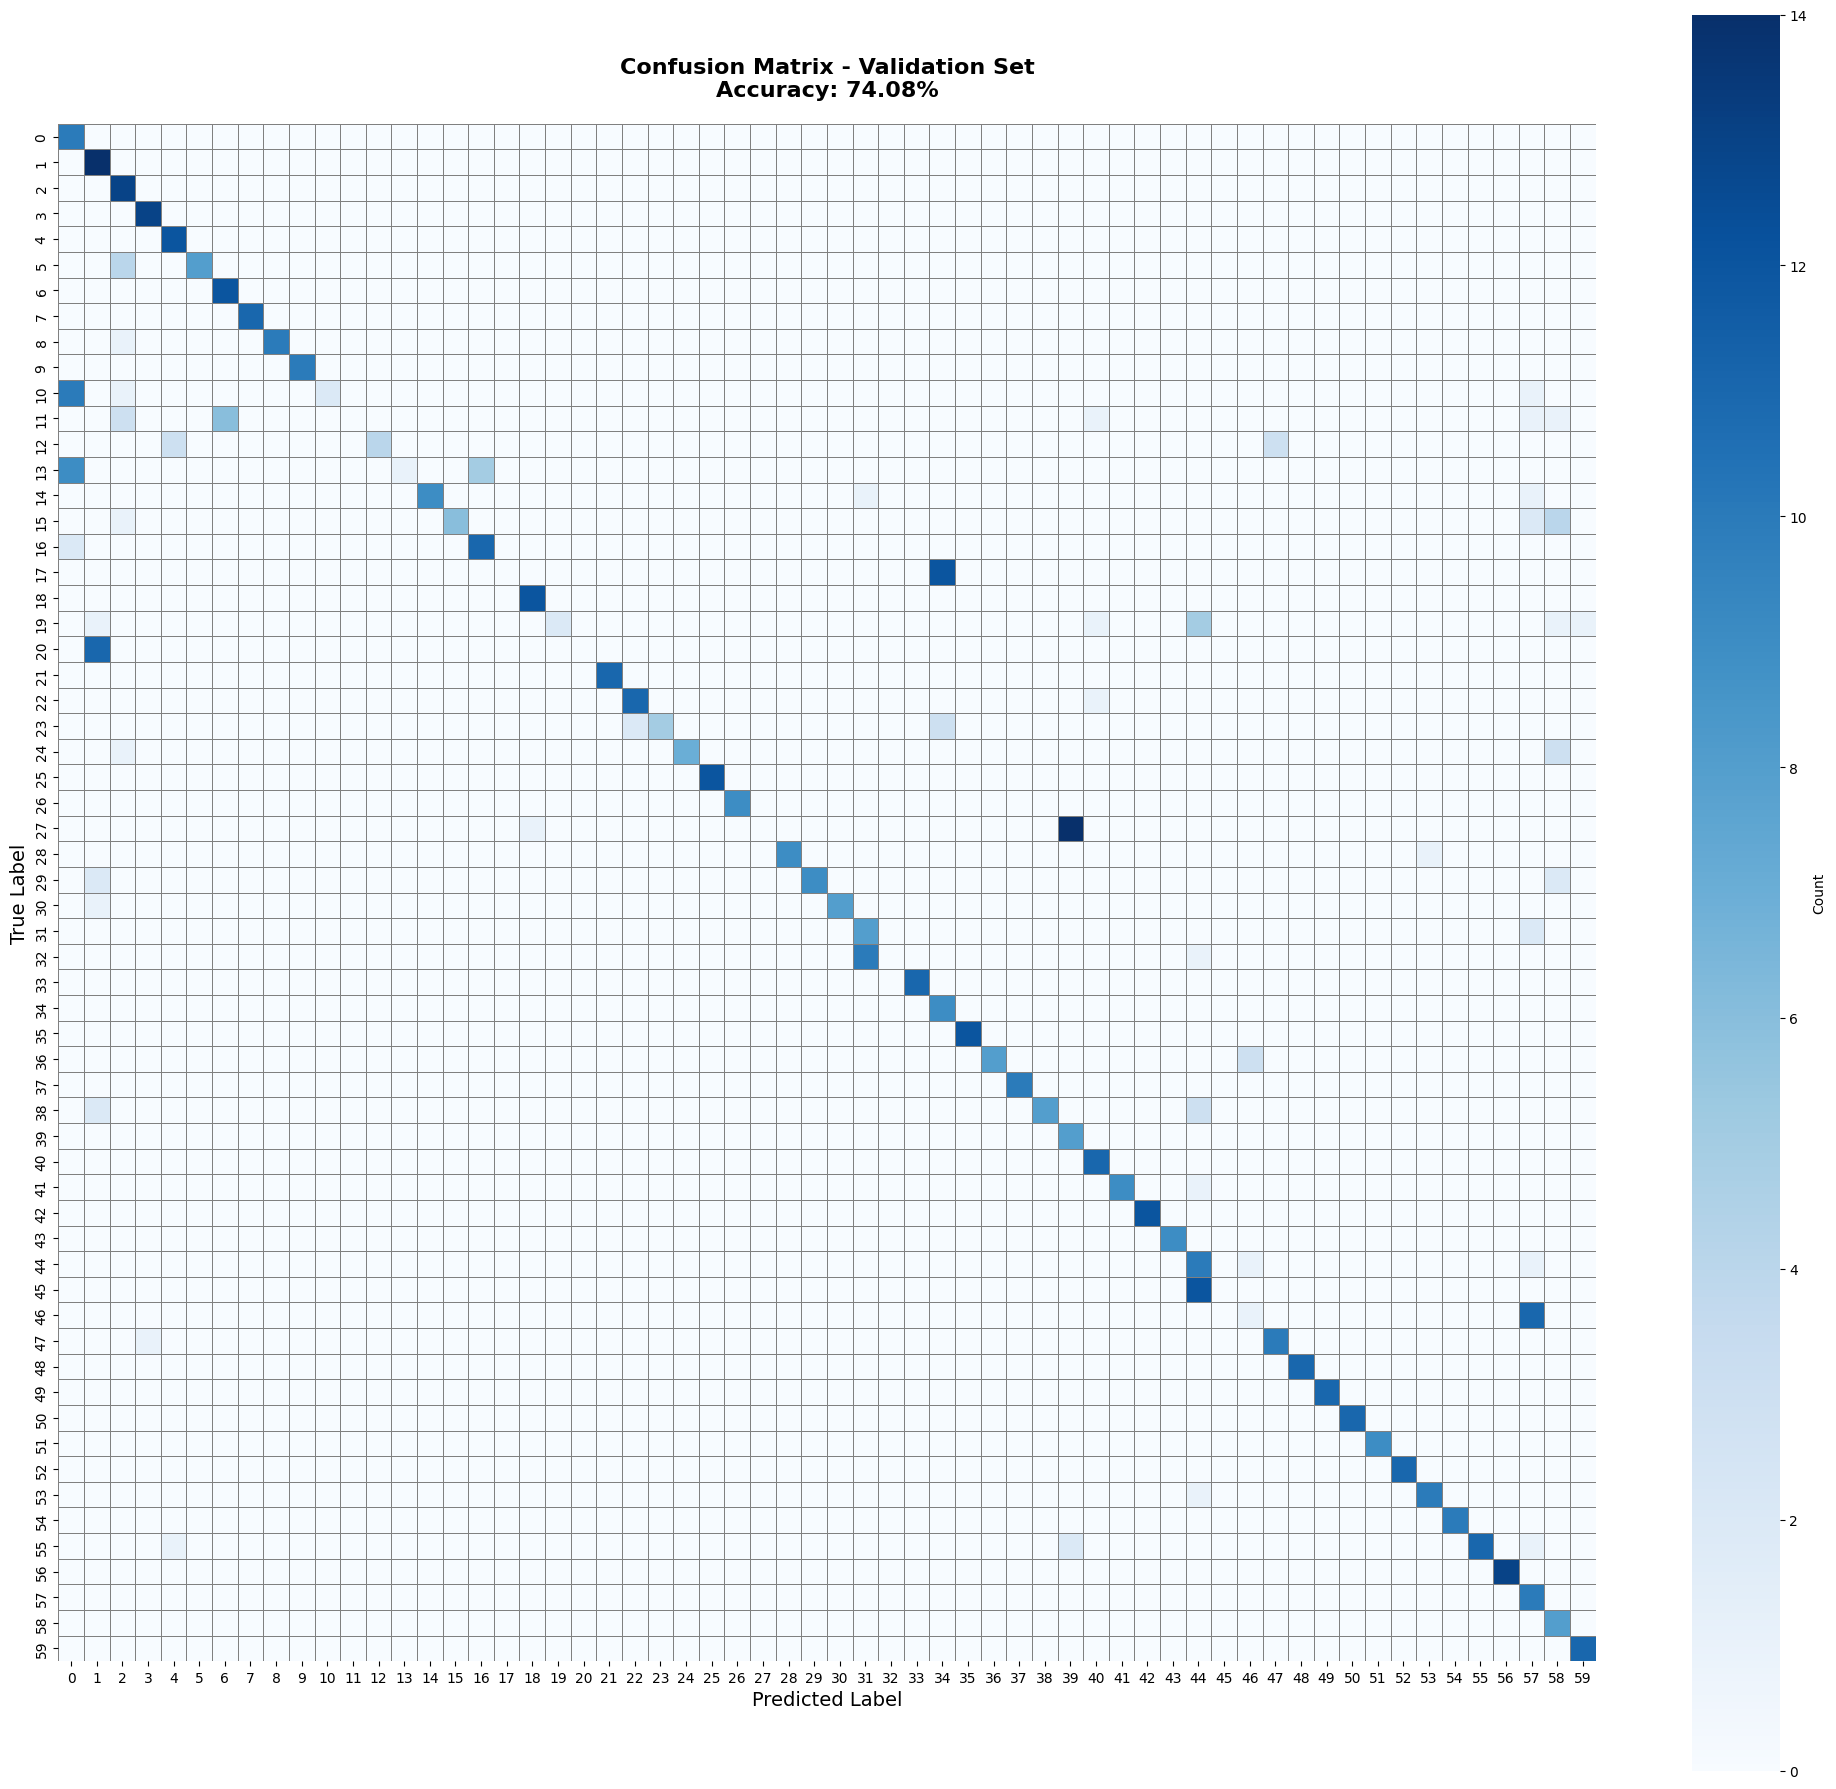

✓ Saved full confusion matrix to /content/confusion_matrix_full.png


In [ ]:
# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')
plt.title(f'Confusion Matrix - Validation Set\nAccuracy: {accuracy*100:.2f}%',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved full confusion matrix to /content/confusion_matrix_full.png")

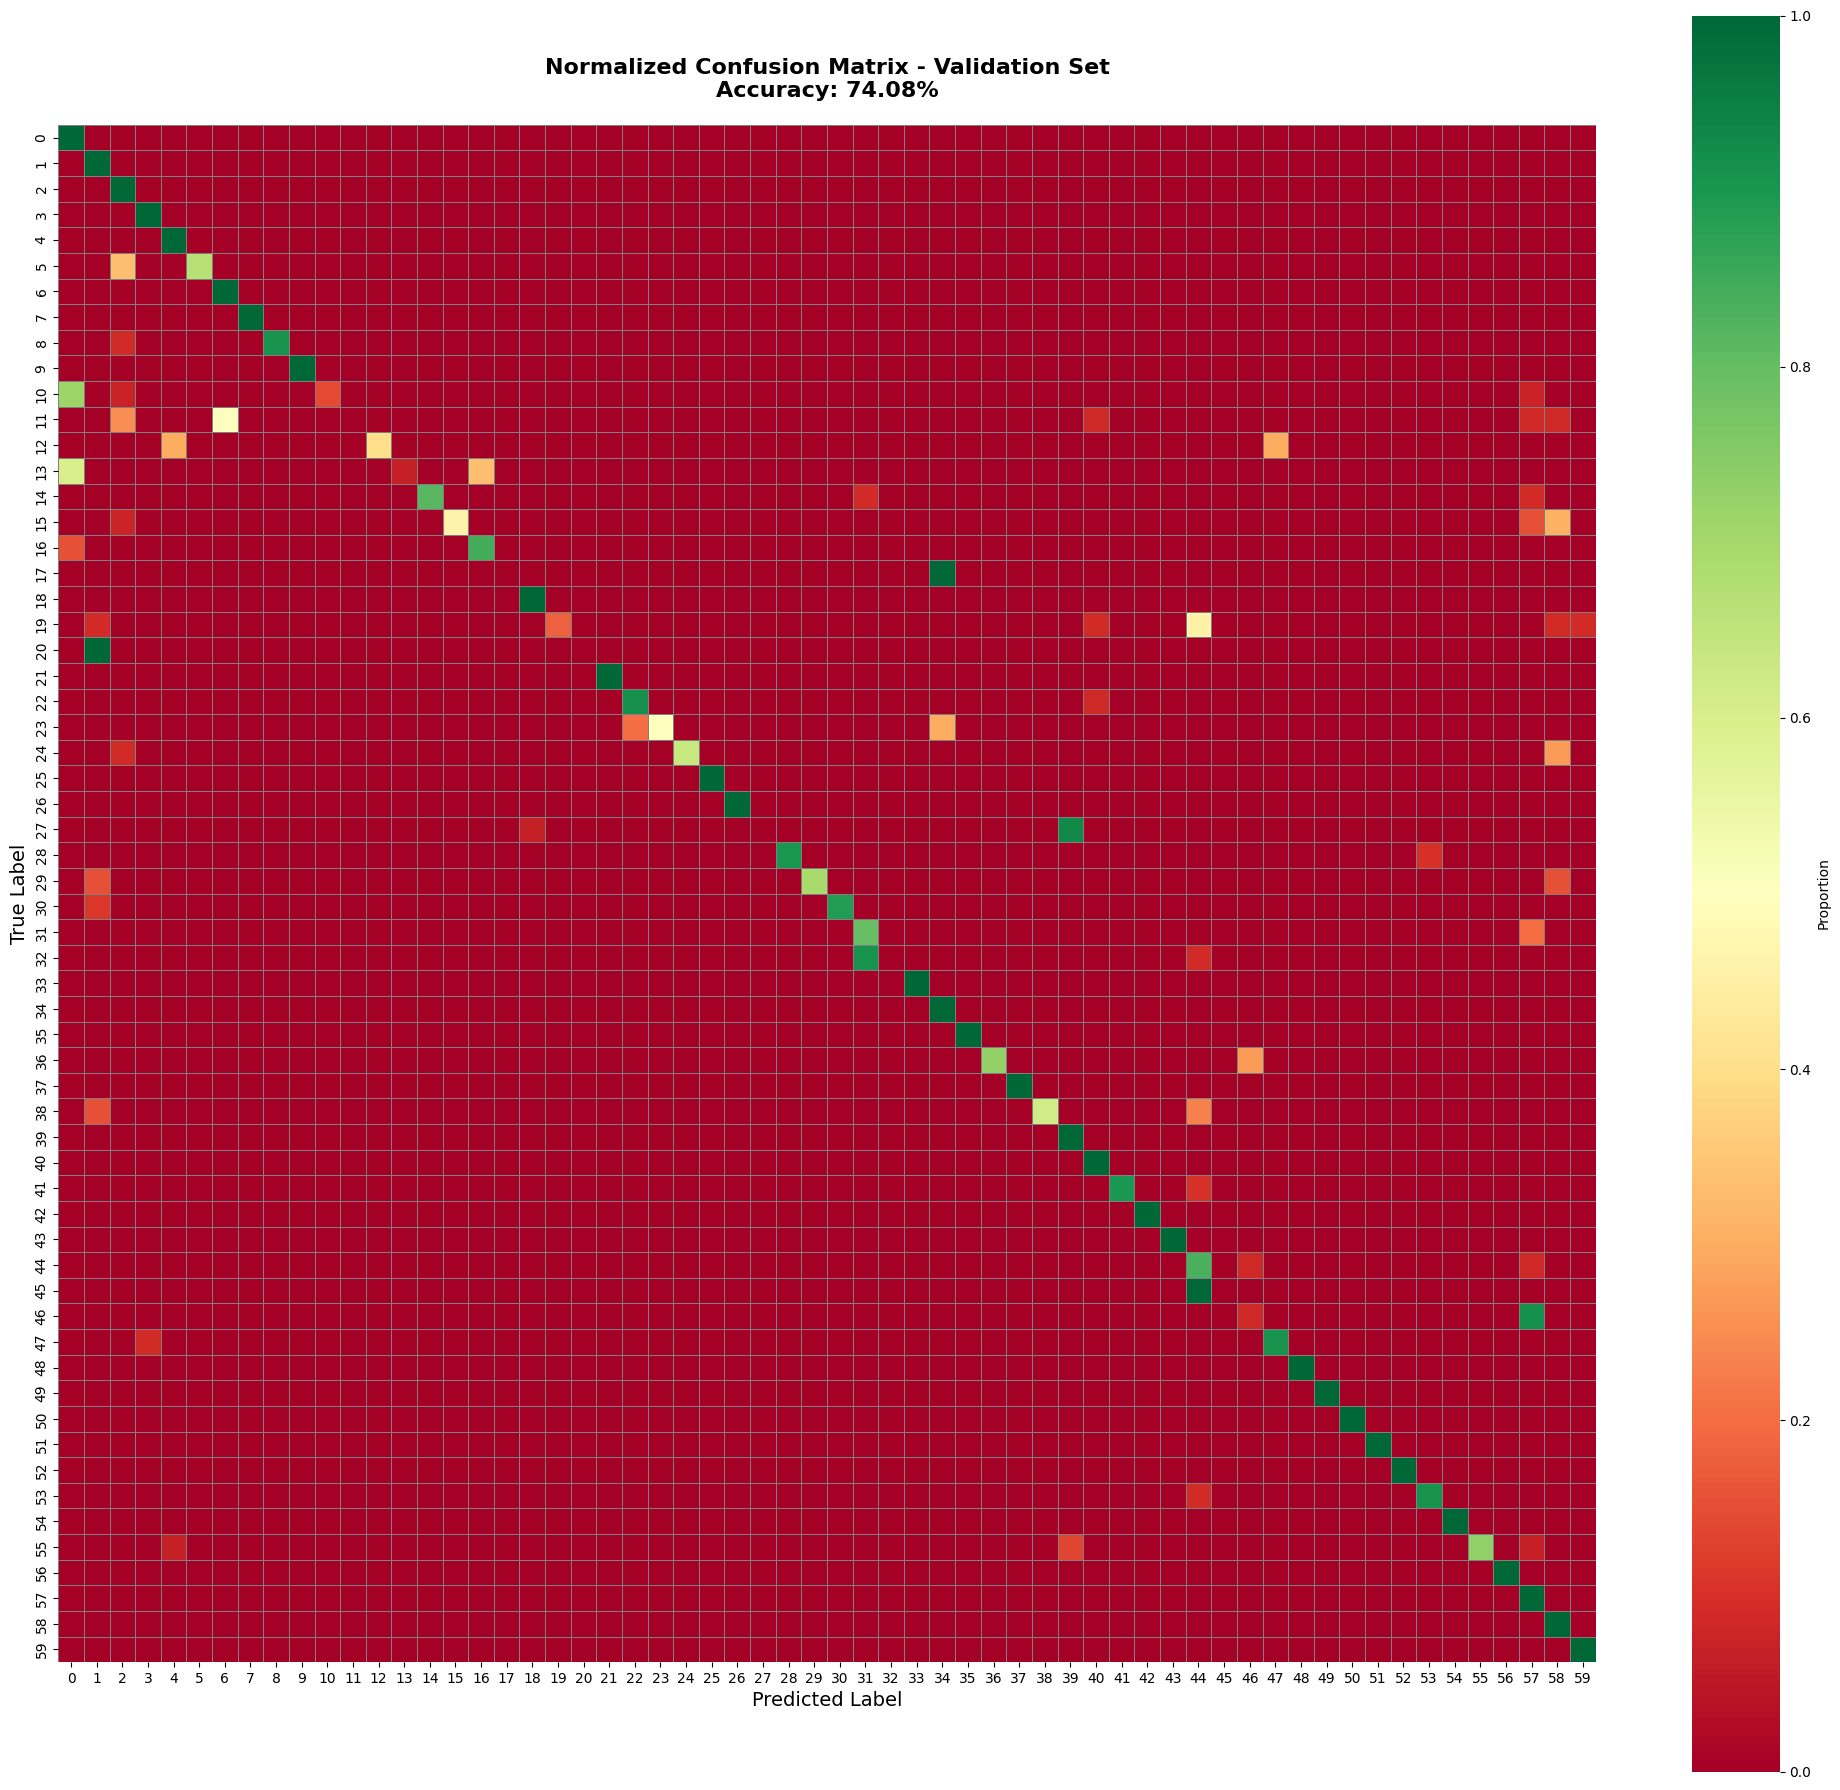

✓ Saved normalized confusion matrix to /content/confusion_matrix_normalized.png


In [ ]:
# Plot normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20, 18))
sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='RdYlGn',
            square=True, vmin=0, vmax=1, cbar_kws={'label': 'Proportion'},
            linewidths=0.5, linecolor='gray')
plt.title(f'Normalized Confusion Matrix - Validation Set\nAccuracy: {accuracy*100:.2f}%',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved normalized confusion matrix to /content/confusion_matrix_normalized.png")

In [ ]:
# Also save normalized confusion matrix
cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=[f'True_{i}' for i in range(CONFIG['num_classes'])],
    columns=[f'Pred_{i}' for i in range(CONFIG['num_classes'])]
)
cm_normalized_df.to_csv('/content/confusion_matrix_normalized.csv')
print("✓ Saved normalized confusion matrix to /content/confusion_matrix_normalized.csv")

✓ Saved normalized confusion matrix to /content/confusion_matrix_normalized.csv


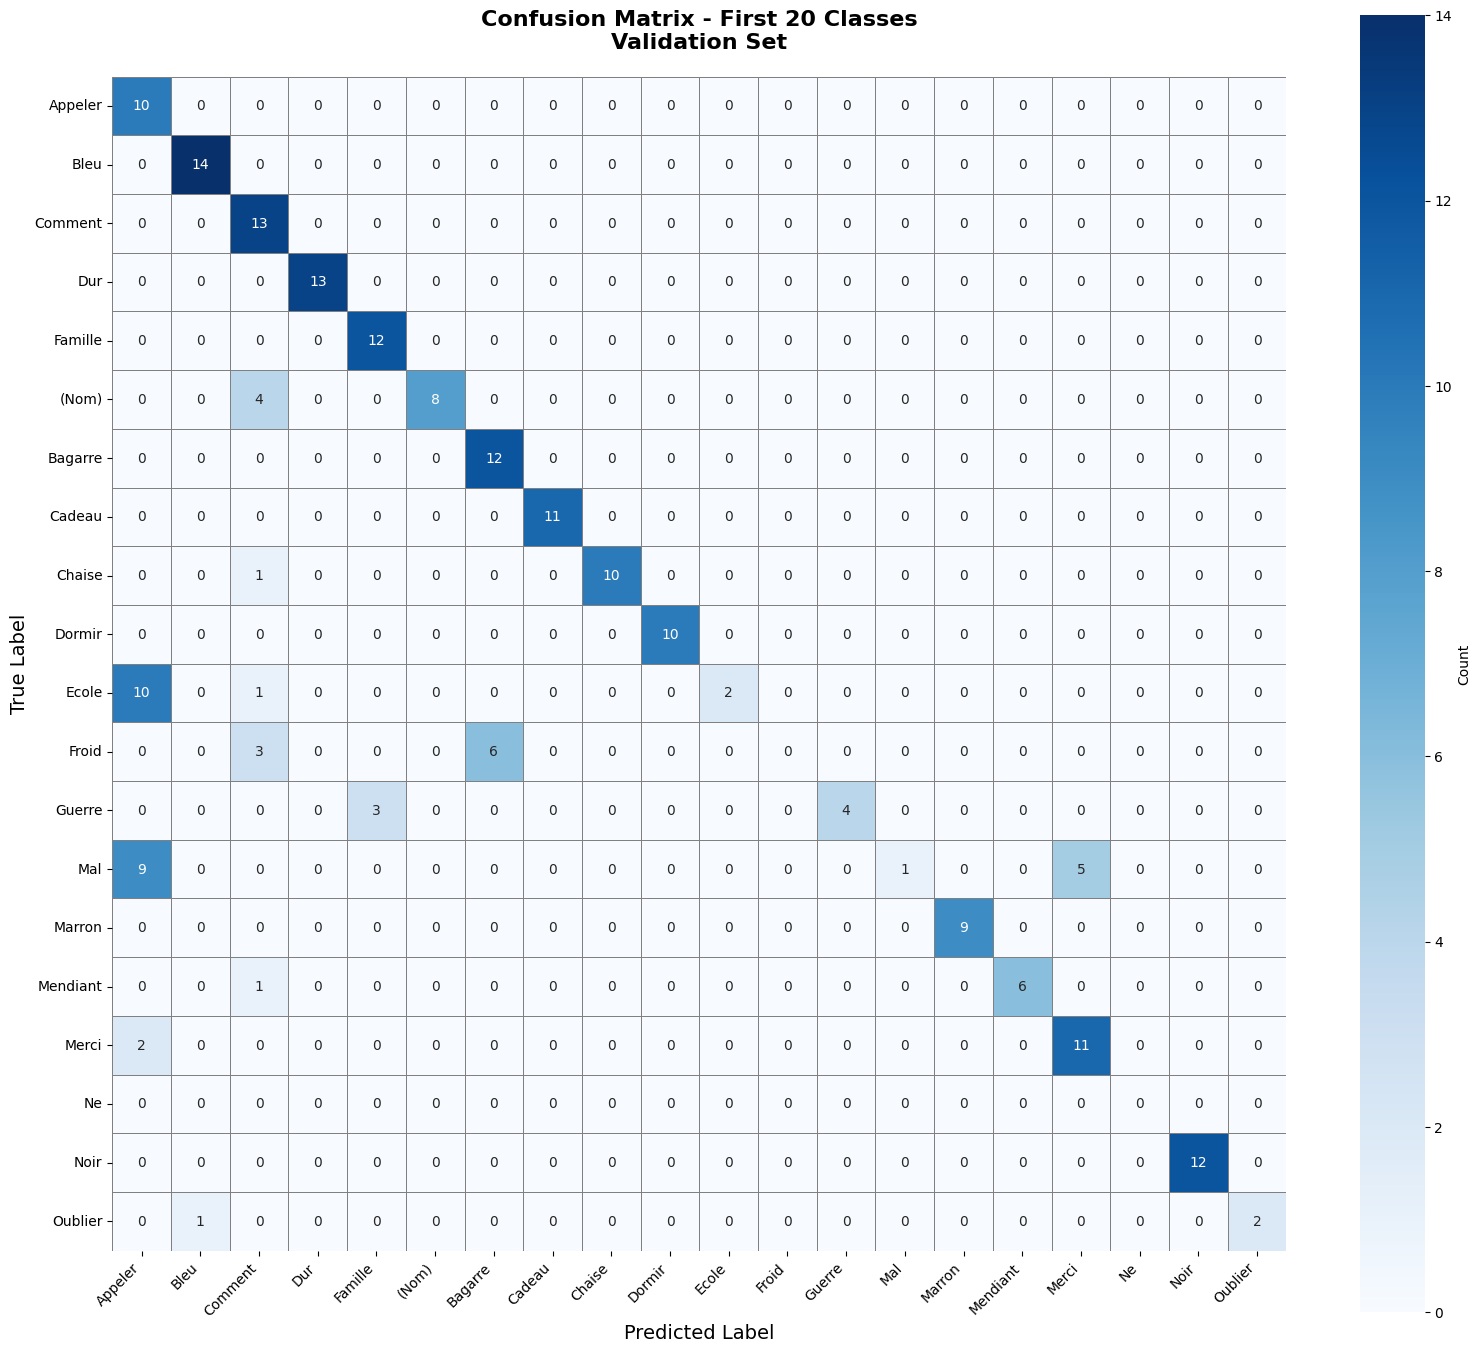

✓ Saved confusion matrix (first 20 classes) to /content/confusion_matrix_first_20.png


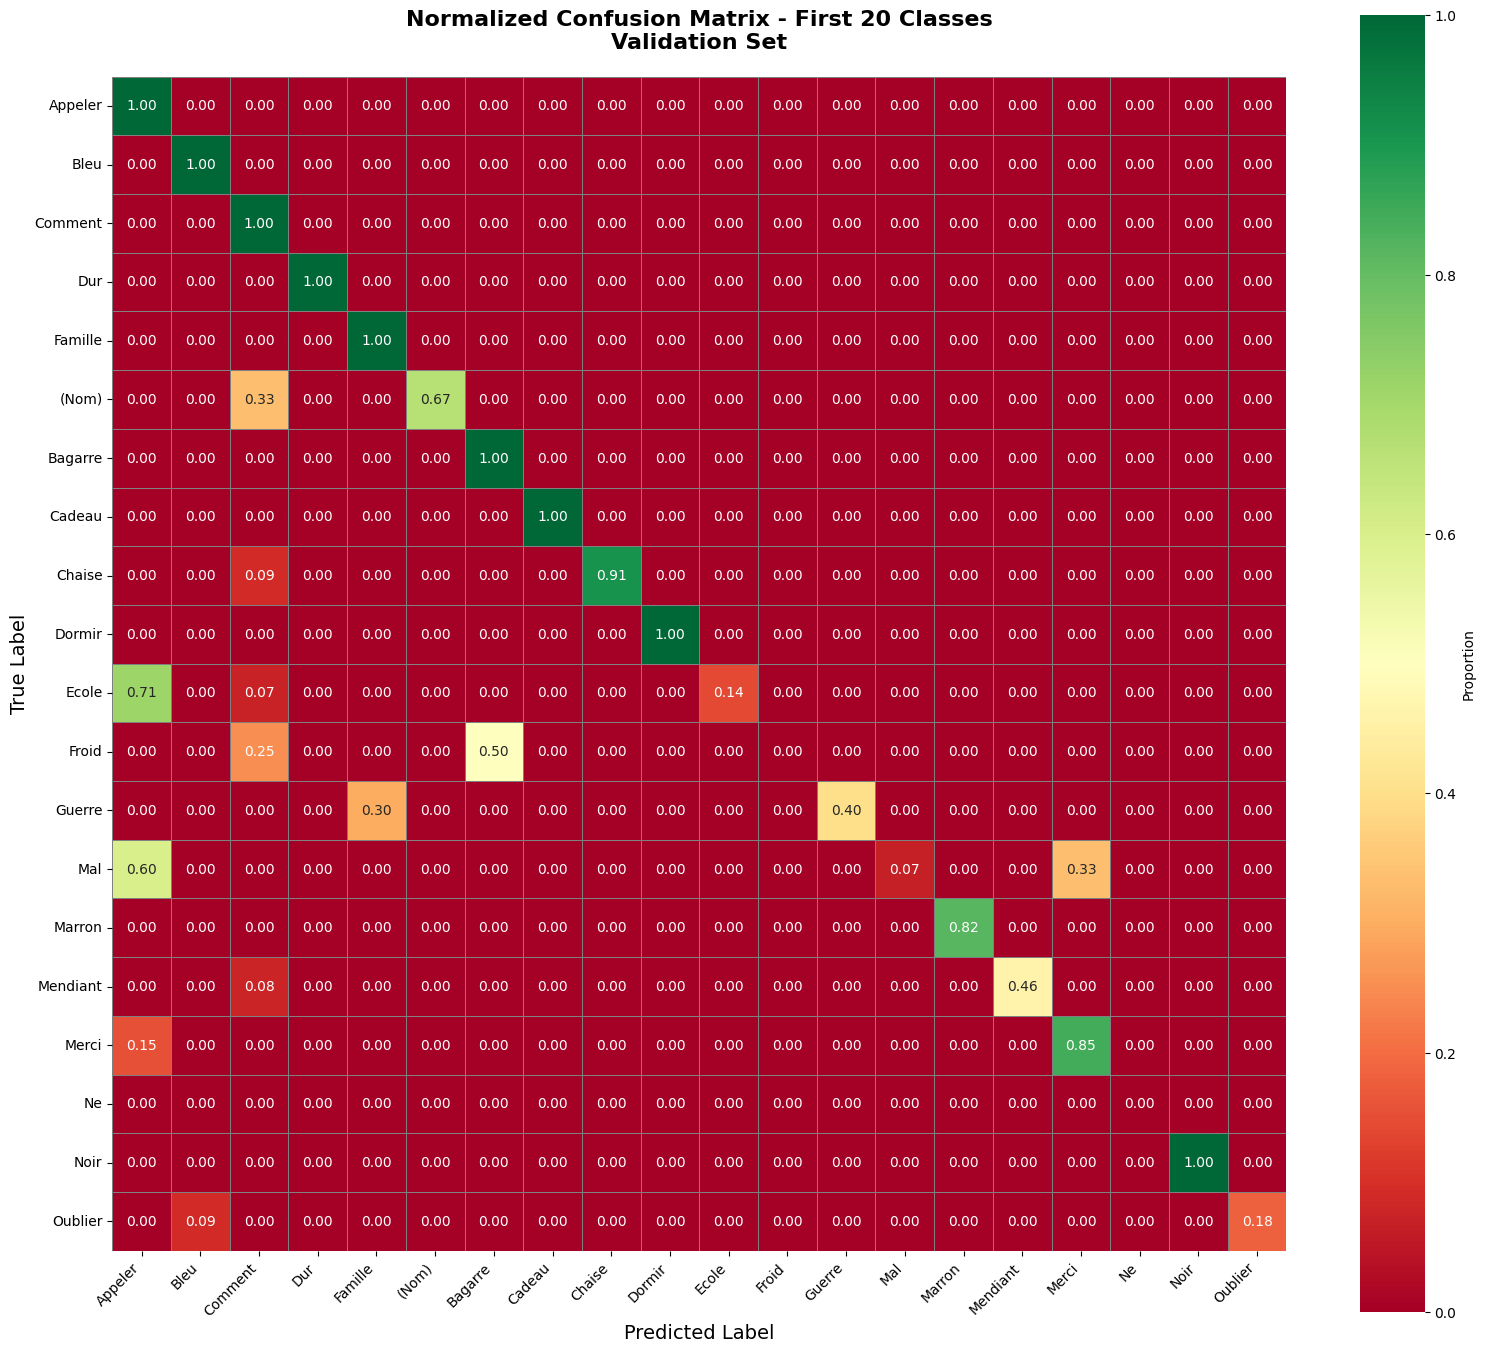

✓ Saved normalized confusion matrix (first 20 classes) to /content/confusion_matrix_normalized_first_20.png


In [ ]:
# Plot confusion matrix for first 20 classes only with labels
num_classes_to_show = 20
cm_subset = cm[:num_classes_to_show, :num_classes_to_show]

# Load labels from labels.json
labels_path = '/content/labels.json'
if os.path.exists(labels_path):
    with open(labels_path, 'r') as f:
        labels_data = json.load(f)

    # Extract short labels (just the word/phrase, not the full string)
    short_labels = []
    for label in labels_data['labels'][:num_classes_to_show]:
        # Extract the main sign name (e.g., "G001 Appeler To call 14" -> "Appeler")
        parts = label.split()
        if len(parts) >= 2:
            # Get the word after the G### code
            short_labels.append(parts[1])
        else:
            short_labels.append(label)
else:
    # Fallback to numerical indices if labels.json not found
    short_labels = [f'{i}' for i in range(num_classes_to_show)]
    print(f"⚠️  labels.json not found at {labels_path}, using numerical indices")

# Plot confusion matrix with labels
plt.figure(figsize=(16, 14))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
            xticklabels=short_labels,
            yticklabels=short_labels)
plt.title(f'Confusion Matrix - First {num_classes_to_show} Classes\nValidation Set',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(f'/content/confusion_matrix_first_{num_classes_to_show}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved confusion matrix (first {num_classes_to_show} classes) to /content/confusion_matrix_first_{num_classes_to_show}.png")

# Also plot normalized version for first 20 classes
cm_normalized_subset = cm_normalized[:num_classes_to_show, :num_classes_to_show]

plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized_subset, annot=True, fmt='.2f', cmap='RdYlGn',
            square=True, vmin=0, vmax=1, cbar_kws={'label': 'Proportion'},
            linewidths=0.5, linecolor='gray',
            xticklabels=short_labels,
            yticklabels=short_labels)
plt.title(f'Normalized Confusion Matrix - First {num_classes_to_show} Classes\nValidation Set',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(f'/content/confusion_matrix_normalized_first_{num_classes_to_show}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved normalized confusion matrix (first {num_classes_to_show} classes) to /content/confusion_matrix_normalized_first_{num_classes_to_show}.png")

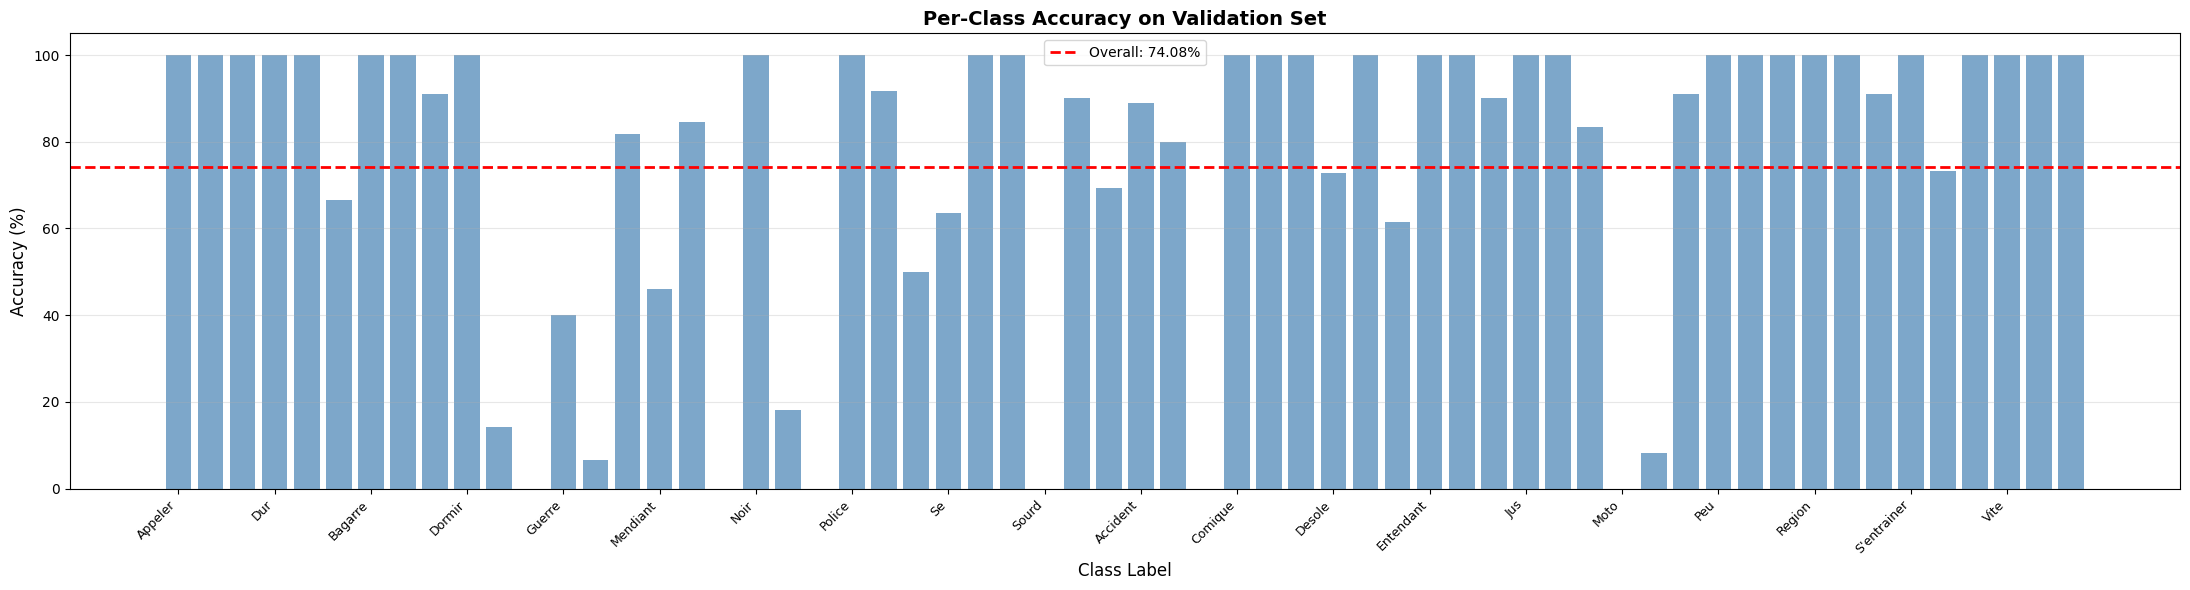

✓ Saved per-class accuracy to /content/per_class_accuracy.png


In [ ]:
# Per-class accuracy analysis with labels
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Load labels from labels.json
labels_path = '/content/labels.json'
if os.path.exists(labels_path):
    with open(labels_path, 'r') as f:
        labels_data = json.load(f)

    # Extract short labels for all classes
    short_labels = []
    for label in labels_data['labels']:
        parts = label.split()
        if len(parts) >= 2:
            short_labels.append(parts[1])
        else:
            short_labels.append(label)

    # Show every 3rd label for readability
    tick_positions = range(0, CONFIG['num_classes'], 3)
    tick_labels = [short_labels[i] if i < len(short_labels) else str(i) for i in tick_positions]
else:
    # Fallback to numerical indices
    tick_positions = range(0, CONFIG['num_classes'], 5)
    tick_labels = [str(i) for i in tick_positions]
    print(f"⚠️  labels.json not found at {labels_path}, using numerical indices")

plt.figure(figsize=(22, 6))
bars = plt.bar(range(CONFIG['num_classes']), class_accuracy * 100, color='steelblue', alpha=0.7)
plt.axhline(y=accuracy*100, color='r', linestyle='--', linewidth=2, label=f'Overall: {accuracy*100:.2f}%')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy on Validation Set', fontsize=14, fontweight='bold')
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right', fontsize=9)
plt.ylim([0, 105])
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved per-class accuracy to /content/per_class_accuracy.png")

In [ ]:
# Find best and worst performing classes
print("\n" + "="*80)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*80)

# Best performing classes
best_indices = np.argsort(class_accuracy)[-10:][::-1]
print("\n🏆 TOP 10 BEST PERFORMING CLASSES:")
for idx in best_indices:
    label_name = short_labels[idx] if 'short_labels' in locals() and idx < len(short_labels) else f"Class {idx}"
    print(f"  {label_name:20s} ({idx:2d}): {class_accuracy[idx]*100:5.2f}% ({cm[idx, idx]}/{cm[idx].sum()} correct)")

# Worst performing classes
worst_indices = np.argsort(class_accuracy)[:10]
print("\n⚠️  TOP 10 WORST PERFORMING CLASSES:")
for idx in worst_indices:
    label_name = short_labels[idx] if 'short_labels' in locals() and idx < len(short_labels) else f"Class {idx}"
    print(f"  {label_name:20s} ({idx:2d}): {class_accuracy[idx]*100:5.2f}% ({cm[idx, idx]}/{cm[idx].sum()} correct)")

print("\n" + "="*80)


PER-CLASS PERFORMANCE ANALYSIS

🏆 TOP 10 BEST PERFORMING CLASSES:
  Vol                  (59): 100.00% (11/11 correct)
  Voiture              (58): 100.00% (8/8 correct)
  Vite                 (57): 100.00% (10/10 correct)
  Vert                 (56): 100.00% (13/13 correct)
  S'entrainer          (54): 100.00% (10/10 correct)
  Rouge                (52): 100.00% (11/11 correct)
  Probleme             (50): 100.00% (11/11 correct)
  Region               (51): 100.00% (9/9 correct)
  Pourquoi             (49): 100.00% (11/11 correct)
  Peu                  (48): 100.00% (11/11 correct)

⚠️  TOP 10 WORST PERFORMING CLASSES:
  Froid                (11):  0.00% (0/12 correct)
  Sourd                (27):  0.00% (0/15 correct)
  Papa                 (20):  0.00% (0/11 correct)
  Ne                   (17):  0.00% (0/12 correct)
  Moto                 (45):  0.00% (0/12 correct)
  Blanc                (32):  0.00% (0/11 correct)
  Mal                  (13):  6.67% (1/15 correct)
  Pas       

In [ ]:
# Detailed classification report
print("\nGenerating detailed classification report...\n")

# Use labels for display if available
if 'short_labels' in locals() and len(short_labels) == CONFIG['num_classes']:
    target_names = short_labels
else:
    target_names = [f"Class_{i}" for i in range(CONFIG['num_classes'])]

report = classification_report(
    all_labels,
    all_predictions,
    target_names=target_names,
    digits=4
)
print(report)

# Save report to file
with open('/content/classification_report.txt', 'w') as f:
    f.write("CASL Multimodal Model - Classification Report\n")
    f.write("="*80 + "\n\n")
    f.write(f"Overall Accuracy: {accuracy*100:.4f}%\n\n")
    f.write(report)

print("✓ Saved classification report to /content/classification_report.txt")



Generating detailed classification report...

               precision    recall  f1-score   support

      Appeler     0.3226    1.0000    0.4878        10
         Bleu     0.4516    1.0000    0.6222        14
      Comment     0.5417    1.0000    0.7027        13
          Dur     0.9286    1.0000    0.9630        13
      Famille     0.7500    1.0000    0.8571        12
        (Nom)     1.0000    0.6667    0.8000        12
      Bagarre     0.6667    1.0000    0.8000        12
       Cadeau     1.0000    1.0000    1.0000        11
       Chaise     1.0000    0.9091    0.9524        11
       Dormir     1.0000    1.0000    1.0000        10
        Ecole     1.0000    0.1429    0.2500        14
        Froid     0.0000    0.0000    0.0000        12
       Guerre     1.0000    0.4000    0.5714        10
          Mal     1.0000    0.0667    0.1250        15
       Marron     1.0000    0.8182    0.9000        11
     Mendiant     1.0000    0.4615    0.6316        13
        Merci    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Find most confused class pairs
print("\n" + "="*80)
print("MOST CONFUSED CLASS PAIRS")
print("="*80)

# Get off-diagonal elements (misclassifications)
confused_pairs = []
for i in range(CONFIG['num_classes']):
    for j in range(CONFIG['num_classes']):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((i, j, cm[i, j]))

# Sort by count
confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 15 most common misclassifications:")
for i, (true_label, pred_label, count) in enumerate(confused_pairs[:15], 1):
    # Use labels for display if available
    if 'short_labels' in locals() and true_label < len(short_labels) and pred_label < len(short_labels):
        true_name = short_labels[true_label]
        pred_name = short_labels[pred_label]
        print(f"{i:2d}. {true_name:15s} ({true_label:2d}) → {pred_name:15s} ({pred_label:2d}): {count:3d} times")
    else:
        print(f"{i:2d}. Class {true_label:2d} → Class {pred_label:2d}: {count:3d} times")

print("\n" + "="*80)



MOST CONFUSED CLASS PAIRS

Top 15 most common misclassifications:
 1. Sourd           (27) → Entendant       (39):  14 times
 2. Ne              (17) → Concentre-toi   (34):  12 times
 3. Moto            (45) → Maman           (44):  12 times
 4. Papa            (20) → Bleu            ( 1):  11 times
 5. Pas             (46) → Vite            (57):  11 times
 6. Ecole           (10) → Appeler         ( 0):  10 times
 7. Blanc           (32) → Bien            (31):  10 times
 8. Mal             (13) → Appeler         ( 0):   9 times
 9. Froid           (11) → Bagarre         ( 6):   6 times
10. Mal             (13) → Merci           (16):   5 times
11. Oublier         (19) → Maman           (44):   5 times
12. (Nom)           ( 5) → Comment         ( 2):   4 times
13. Mendiant        (15) → Voiture         (58):   4 times
14. Froid           (11) → Comment         ( 2):   3 times
15. Guerre          (12) → Famille         ( 4):   3 times




TRAINING HISTORY
n================================================================================


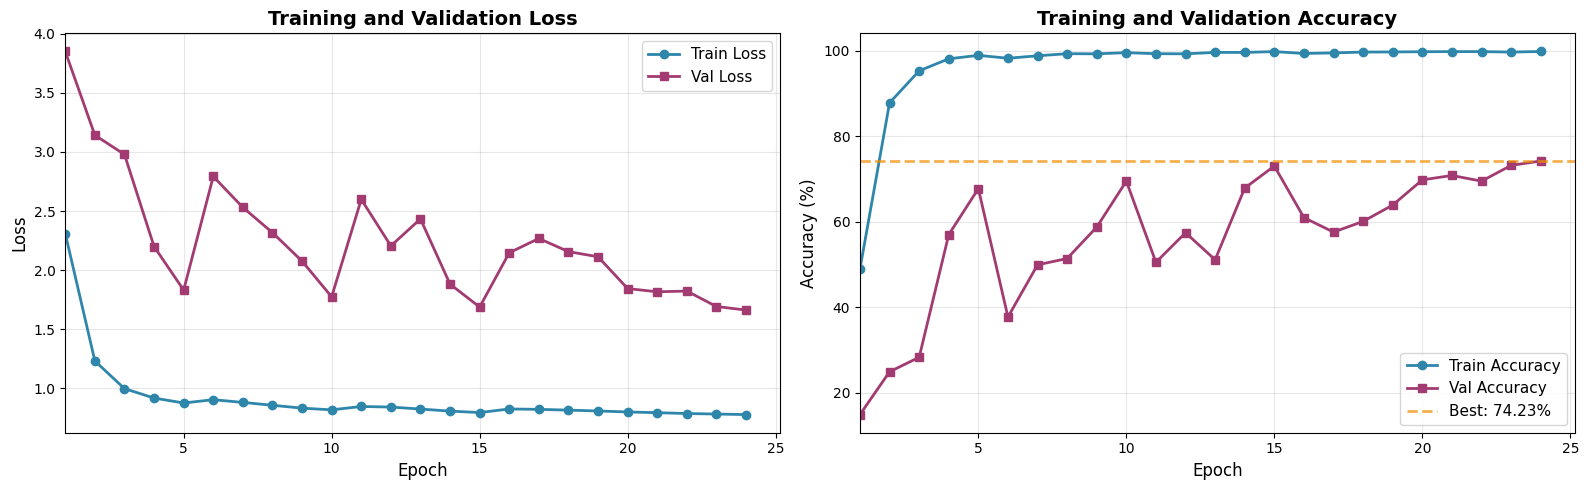


✓ Loaded training history: 24 epochs
✓ Best validation accuracy: 74.23%
✓ Final validation accuracy: 74.23%
✓ Saved training history plot to /content/training_history.png



In [ ]:
# Plot training history from history.json
print("\n" + "="*80)
print("TRAINING HISTORY")
print("n" + "="*80)

history_path = '/content/history.json'
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = list(range(1, len(history['train_loss']) + 1))  # Start at 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', linewidth=2, markersize=6, color='#2E86AB')
    ax1.plot(epochs, history['val_loss'], 's-', label='Val Loss', linewidth=2, markersize=6, color='#A23B72')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(left=1)

    # Accuracy plot
    train_acc_percent = [x*100 for x in history['train_acc']]
    val_acc_percent = [x*100 for x in history['val_acc']]
    best_val_acc = max(history['val_acc']) * 100

    ax2.plot(epochs, train_acc_percent, 'o-', label='Train Accuracy', linewidth=2, markersize=6, color='#2E86AB')
    ax2.plot(epochs, val_acc_percent, 's-', label='Val Accuracy', linewidth=2, markersize=6, color='#A23B72')
    ax2.axhline(y=best_val_acc, color='#F18F01', linestyle='--', linewidth=2, alpha=0.7, label=f'Best: {best_val_acc:.2f}%')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=1)

    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Loaded training history: {len(history['train_loss'])} epochs")
    print(f"✓ Best validation accuracy: {best_val_acc:.2f}%")
    print(f"✓ Final validation accuracy: {val_acc_percent[-1]:.2f}%")
    print(f"✓ Saved training history plot to /content/training_history.png")
else:
    print(f"\n⚠️  history.json not found at {history_path}")
    print("Please upload history.json to /content/ to visualize training history")

print("\n" + "="*80)

In [ ]:
# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal samples: {len(all_labels)}")
print(f"Number of classes: {CONFIG['num_classes']}")
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")
print(f"Mean per-class accuracy: {np.mean(class_accuracy)*100:.2f}%")
print(f"Std per-class accuracy: {np.std(class_accuracy)*100:.2f}%")
print(f"\nBest class accuracy: {np.max(class_accuracy)*100:.2f}% (Class {np.argmax(class_accuracy)})")
print(f"Worst class accuracy: {np.min(class_accuracy)*100:.2f}% (Class {np.argmin(class_accuracy)})")
print(f"\nTotal correct predictions: {np.sum(cm.diagonal())}")
print(f"Total incorrect predictions: {np.sum(cm) - np.sum(cm.diagonal())}")
print("\n" + "="*80)

print("\n✅ Analysis complete!")
print("\nGenerated files:")
print("  - confusion_matrix_full.png")
print("  - confusion_matrix_normalized.png")
print("  - per_class_accuracy.png")
print("  - training_history.png (if history.json was uploaded)")
print("  - classification_report.txt")


SUMMARY STATISTICS

Total samples: 679
Number of classes: 60

Overall Accuracy: 74.08%
Mean per-class accuracy: 75.90%
Std per-class accuracy: 35.00%

Best class accuracy: 100.00% (Class 0)
Worst class accuracy: 0.00% (Class 11)

Total correct predictions: 503
Total incorrect predictions: 176


✅ Analysis complete!

Generated files:
  - confusion_matrix_full.png
  - confusion_matrix_normalized.png
  - per_class_accuracy.png
  - training_history.png (if history.json was uploaded)
  - classification_report.txt


In [ ]:
# Save per-class accuracy to CSV
per_class_df = pd.DataFrame({
    'Class_Index': range(CONFIG['num_classes']),
    'Class_Name': short_labels if 'short_labels' in locals() and len(short_labels) == CONFIG['num_classes'] else [f"Class_{i}" for i in range(CONFIG['num_classes'])],
    'Accuracy': class_accuracy,
    'Accuracy_Percent': class_accuracy * 100,
    'Correct_Predictions': cm.diagonal(),
    'Total_Samples': cm.sum(axis=1)
})

per_class_df.to_csv('/content/per_class_accuracy.csv', index=False)
print("✓ Saved per-class accuracy to /content/per_class_accuracy.csv")

✓ Saved per-class accuracy to /content/per_class_accuracy.csv


In [ ]:
# Save training history to CSV
history_df = pd.DataFrame({
    'Epoch': epochs,
    'Train_Loss': history['train_loss'],
    'Val_Loss': history['val_loss'],
    'Train_Accuracy': [x*100 for x in history['train_acc']],
    'Val_Accuracy': [x*100 for x in history['val_acc']]
})
history_df.to_csv('/content/training_history.csv', index=False)
print("✓ Saved training history to /content/training_history.csv")

✓ Saved training history to /content/training_history.csv


In [14]:
!pip uninstall -y numpy
!pip install numpy==1.26.4 mediapipe opencv-python-headless scikit-learn torchvision -q

print("\n🚀 IMPORTANT: You MUST click 'Runtime' -> 'Restart Session' in the top menu now.")
print("After restarting, DO NOT run any old cells. Only run the Evaluation Cell below.")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.

🚀 IMPORTA

In [11]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14 opencv-python-headless scikit-learn torchvision -q

Found existing installation: mediapipe 0.10.32
Uninstalling mediapipe-0.10.32:
  Successfully uninstalled mediapipe-0.10.32
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 whi

In [15]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
from torchvision.models.video import mvit_v2_s
import kagglehub

# --- 1. ROBUST MEDIAPIPE IMPORT ---
import mediapipe as mp
try:
    from mediapipe.python.solutions import hands as mp_hands
except:
    import mediapipe.solutions.hands as mp_hands

# --- 2. SETUP PATHS & DEVICE ---
MODEL_PATH = '/content/best_multimodal_model (3).pth'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_path = '/kaggle/input/casl-w60'
if not os.path.exists(dataset_path):
    dataset_path = kagglehub.dataset_download("mwakalucky/casl-w60")
TEST_DIR = os.path.join(dataset_path, "CASL/val")

# --- 3. CORRECTED ARCHITECTURE (5D Video-Aware) ---
class MultimodalBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        # RGB Backbone (MViT V2 S)
        self.rgb_backbone = mvit_v2_s(weights=None)
        rgb_dim = self.rgb_backbone.head[1].in_features
        self.rgb_backbone.head = nn.Identity()

        # Pose Backbone (126 features)
        self.pose_lstm = nn.LSTM(126, 256, num_layers=2, batch_first=True, bidirectional=True)

        # Fusion Head
        self.fusion = nn.Sequential(
            nn.Linear(rgb_dim + 512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 60)
        )

    def forward(self, rgb, pose):
        # rgb: [Batch, Channels, Time, Height, Width]
        # MViT expects 5D. We pass it directly.
        rgb_feat = self.rgb_backbone(rgb)

        # If backbone returns a sequence, pool it to a single vector
        if len(rgb_feat.shape) > 2:
            rgb_feat = rgb_feat.mean(dim=1)

        # Process Pose
        pose_feat, _ = self.pose_lstm(pose)
        pose_feat = pose_feat[:, -1, :] # Last state

        return self.fusion(torch.cat([rgb_feat, pose_feat], dim=1))

# --- 4. DATA LOADER (Ensuring Float Tensors) ---
class CASLMultimodalTestSet(Dataset):
    def __init__(self, directory):
        self.files = sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.mp4')])
        self.detector = mp_hands.Hands(static_image_mode=False, max_num_hands=2)
        self.transform = transforms.Compose([
            transforms.ToPILImage(), transforms.Resize((224, 224)),
            transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = int(os.path.basename(path)[1:4]) - 1
        cap = cv2.VideoCapture(path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            frames.append(frame)
        cap.release()

        indices = np.linspace(0, len(frames)-1, 16, dtype=int)
        rgb_list, pose_list = [], []
        for i in indices:
            f = frames[i]
            res = self.detector.process(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            pts = []
            if res.multi_hand_landmarks:
                for h in res.multi_hand_landmarks[:2]:
                    for lm in h.landmark: pts.extend([lm.x, lm.y, lm.z])
            while len(pts) < 126: pts.extend([0.0] * 63)
            pose_list.append(pts[:126])
            rgb_list.append(self.transform(f))

        # [Channels, Time, Height, Width] -> e.g. [3, 16, 224, 224]
        rgb_tensor = torch.stack(rgb_list).permute(1, 0, 2, 3)
        return rgb_tensor, torch.tensor(np.stack(pose_list), dtype=torch.float32), label

# --- 5. EXECUTION ---
if not os.path.exists(MODEL_PATH):
    print(f"❌ Error: Model file not found at {MODEL_PATH}")
else:
    print(f"🚀 Finalizing Tournament Evaluation for {os.path.basename(MODEL_PATH)}...")
    model = MultimodalBaseline().to(DEVICE)
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
    model.eval()

    test_loader = DataLoader(CASLMultimodalTestSet(TEST_DIR), batch_size=4, shuffle=False)
    all_probs, all_targets = [], []

    with torch.no_grad():
        for rgb, pose, labels in tqdm(test_loader, desc="Calculating Ranks"):
            # Move both to GPU correctly
            output = model(rgb.to(DEVICE).float(), pose.to(DEVICE))
            all_probs.append(torch.softmax(output, dim=1).cpu().numpy())
            all_targets.extend(labels.numpy())

    # --- 6. CALCULATE ROBUSTNESS METRICS ---
    all_probs = np.vstack(all_probs)
    all_targets = np.array(all_targets)
    sorted_indices = np.argsort(all_probs, axis=1)[:, ::-1]
    ranks = [np.where(sorted_indices[i] == all_targets[i])[0][0] + 1 for i in range(len(all_targets))]

    print(f"\n📊 --- EXO-01 (MULTIMODAL) ROBUSTNESS RESULTS ---")
    print(f"Recall @ 1:  {np.mean([1 if r <= 1 else 0 for r in ranks])*100:.2f}%")
    print(f"Recall @ 5:  {np.mean([1 if r <= 5 else 0 for r in ranks])*100:.2f}%")
    print(f"Recall @ 10: {np.mean([1 if r <= 10 else 0 for r in ranks])*100:.2f}%")
    print(f"Median Rank: {np.median(ranks)}")

🚀 Finalizing Tournament Evaluation for best_multimodal_model (3).pth...


Calculating Ranks:   0%|          | 0/170 [00:00<?, ?it/s]


📊 --- EXO-01 (MULTIMODAL) ROBUSTNESS RESULTS ---
Recall @ 1:  29.90%
Recall @ 5:  57.00%
Recall @ 10: 73.78%
Median Rank: 4.0
